# Notebook 03: Exploratory Data Analysis

### Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Load Dataframe

In [2]:
df = pd.read_csv('../data/processed/merged_df.csv')

In [3]:
# look at dimensions and preview df
print(df.shape)
print(df.head())

(5457, 24)
   Unnamed: 0  SEASON     PLAYER_NAME  GP   MIN   PTS  REB  AST  STL  BLK  \
0           0    2000      A.C. Green  82  23.5   5.0  5.9  1.0  0.6  0.2   
1           1    2000     Aaron McKie  82  23.8   8.0  3.0  2.9  1.3  0.2   
2           2    2000    Adonal Foyle  76  21.7   5.5  5.6  0.6  0.3  1.8   
3           3    2000  Adrian Griffin  72  26.8   6.7  5.2  2.5  1.6  0.2   
4           4    2000  Alan Henderson  82  33.9  13.2  7.0  0.9  1.0  0.7   

   ...  FG_PCT  FG3_PCT  FT_PCT  PLUS_MINUS              TEAM_NAME  TEAM_W  \
0  ...   0.447    0.250   0.695         328     Los Angeles Lakers      67   
1  ...   0.411    0.364   0.829          52     Philadelphia 76ers      49   
2  ...   0.508    0.000   0.378        -349  Golden State Warriors      19   
3  ...   0.424    0.281   0.753         -31         Boston Celtics      35   
4  ...   0.461    0.100   0.671        -381          Atlanta Hawks      28   

   TEAM_L  W_PCT W_RANK  MVP_SHARE  
0      15  0.817    

### Identify Frequency of MVP Vote-Getters

In [5]:
print(f"Players from 2000 to 2026 that recieved MVP votes: {(df['MVP_SHARE'] > 0).sum()}")
print(f"Average vote-getters per season: {(df['MVP_SHARE'] > 0).sum() / df['SEASON'].nunique():.1f}")

Players from 2000 to 2026 that recieved MVP votes: 363
Average vote-getters per season: 13.4


### Look at Distribution of MVP Shares

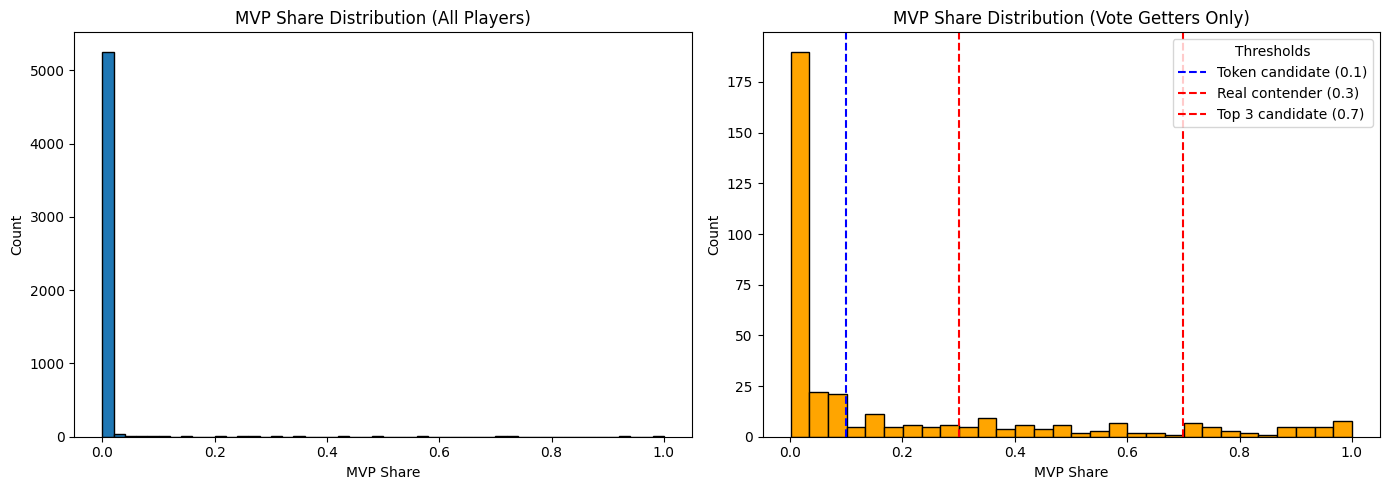

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# left plot - all players
axes[0].hist(df['MVP_SHARE'], bins=50, edgecolor='black')
axes[0].set_title('MVP Share Distribution (All Players)')
axes[0].set_xlabel('MVP Share')
axes[0].set_ylabel('Count')

# right plot - only vote getters
vote_getters = df[df['MVP_SHARE'] > 0]
axes[1].hist(vote_getters['MVP_SHARE'], bins=30, edgecolor='black', color='orange')

# add threshold lines
axes[1].axvline(x=0.1, color='blue', linestyle='--', label='Token candidate (0.1)')
axes[1].axvline(x=0.3, color='red', linestyle='--', label='Real contender (0.3)')
axes[1].axvline(x=0.7, color='red', linestyle='--', label='Top 3 candidate (0.7)')

axes[1].set_title('MVP Share Distribution (Vote Getters Only)')
axes[1].set_xlabel('MVP Share')
axes[1].set_ylabel('Count')
axes[1].legend(loc='upper right', title='Thresholds')

plt.tight_layout()
plt.show()

In [13]:
# look at the count of mvp vote getters at each threshold
print(f"Token candidates (share > 0.1): {(df['MVP_SHARE'] > 0.1).sum()}")
print(f"Real contenders (share > 0.3): {(df['MVP_SHARE'] > 0.3).sum()}")
print(f"MVP winners (share > 0.7): {(df['MVP_SHARE'] > 0.7).sum()}")

Token candidates (share > 0.1): 130
Real contenders (share > 0.3): 92
MVP winners (share > 0.7): 41


### Look at Share Distribution of MVP Winners

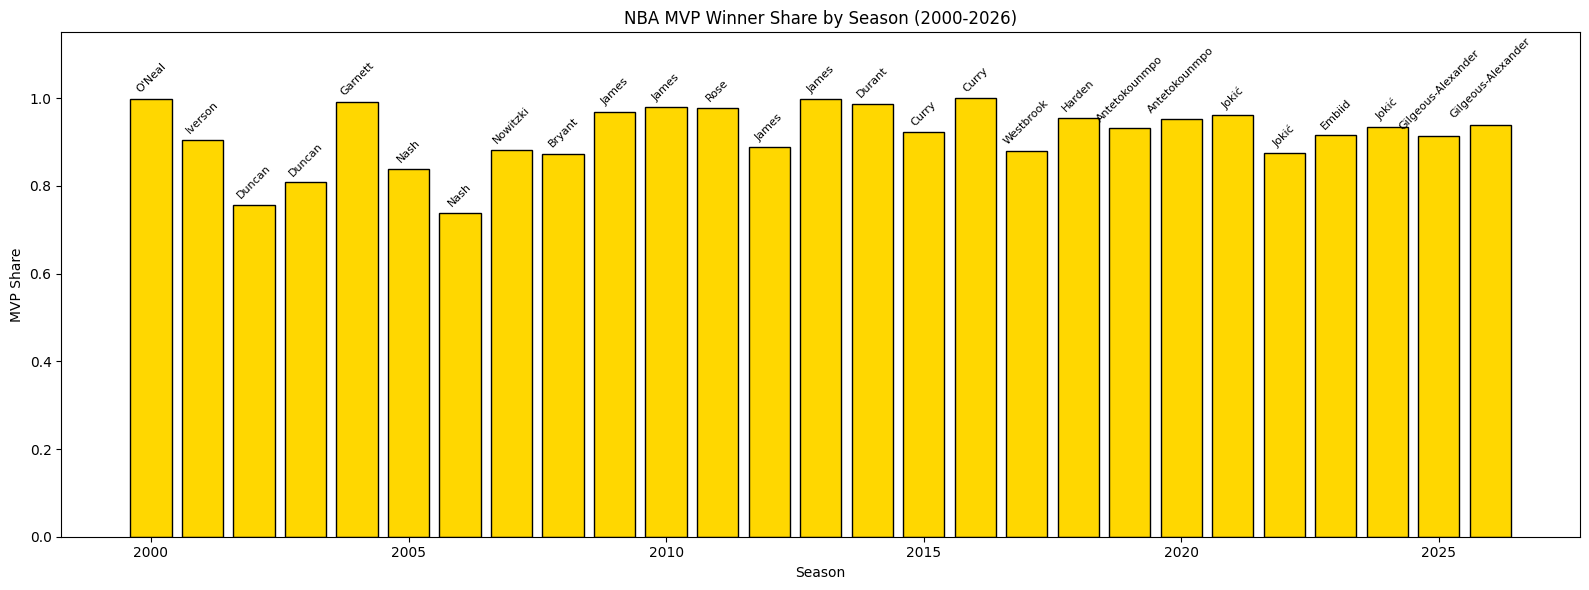

In [16]:
mvp_winners = df.loc[df.groupby('SEASON')['MVP_SHARE'].idxmax()]

# create plot to show mvp winning shares over time
fig, ax = plt.subplots(figsize=(16,6))
ax.bar(mvp_winners['SEASON'], mvp_winners['MVP_SHARE'], color='gold', edgecolor='black')

# annotate with player names
for _, row in mvp_winners.iterrows():
    ax.text(row['SEASON'], row['MVP_SHARE'] + 0.01, 
            row['PLAYER_NAME'].split()[-1],  # last name only
            ha='center', va='bottom', fontsize=8, rotation=45)

ax.set_title('NBA MVP Winner Share by Season (2000-2026)')
ax.set_xlabel('Season')
ax.set_ylabel('MVP Share')
ax.set_ylim(0, 1.15)
plt.tight_layout()
plt.show()

### Identify Best Predictors of MVP Share

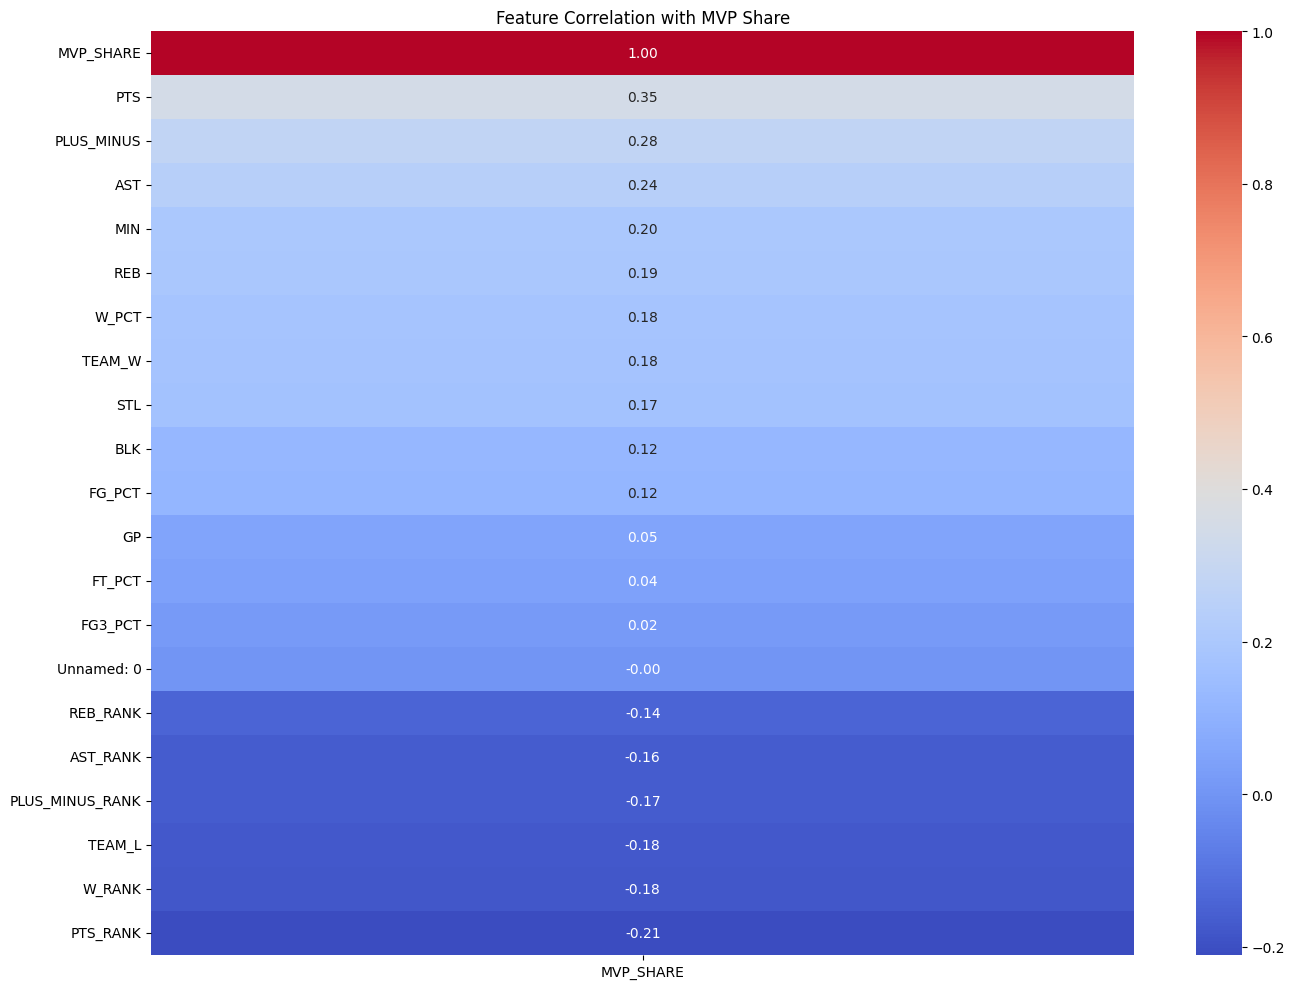

In [19]:
# only numeric features, exclude identifiers
feature_cols = [col for col in df.columns 
                if col not in ['SEASON', 'PLAYER_NAME', 'TEAM_NAME', 'MVP_SHARE']]

corr = df[feature_cols + ['MVP_SHARE']].corr()

fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(corr[['MVP_SHARE']].sort_values('MVP_SHARE', ascending=False),
            annot=True, fmt='.2f', cmap='coolwarm', ax=ax)
ax.set_title('Feature Correlation with MVP Share')
plt.tight_layout()
plt.show()

### Visualize Top Correlated Features in Non-Vote-Getters and Vote-Getters

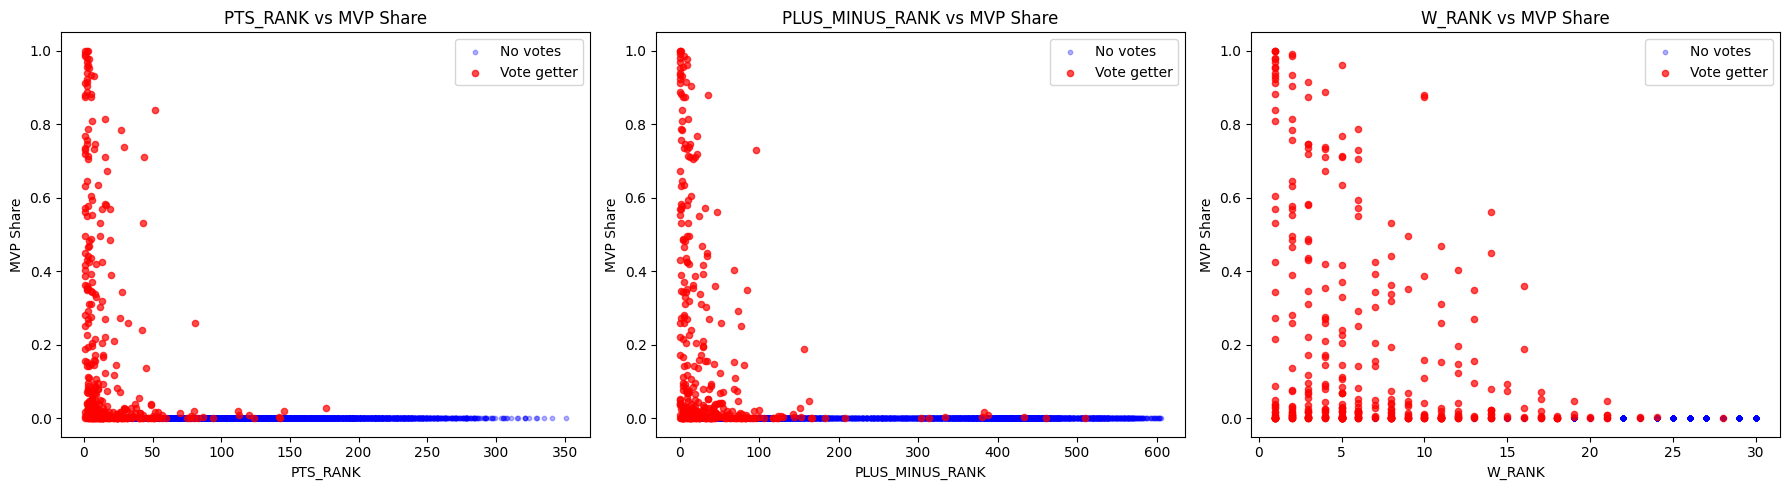

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

features = ['PTS_RANK', 'PLUS_MINUS_RANK', 'W_RANK']

for ax, feature in zip(axes, features):
    # non vote getters
    ax.scatter(df[df['MVP_SHARE'] == 0][feature],
               df[df['MVP_SHARE'] == 0]['MVP_SHARE'],
               alpha=0.3, color='blue', label='No votes', s=10)
    
    # vote getters
    ax.scatter(df[df['MVP_SHARE'] > 0][feature],
               df[df['MVP_SHARE'] > 0]['MVP_SHARE'],
               alpha=0.7, color='red', label='Vote getter', s=20)
    
    ax.set_xlabel(feature)
    ax.set_ylabel('MVP Share')
    ax.set_title(f'{feature} vs MVP Share')
    ax.legend()

plt.tight_layout()
plt.show()

### Visualize Difference in Highly Correlated Metrics for Non-Vote-Getters and Vote-Getters

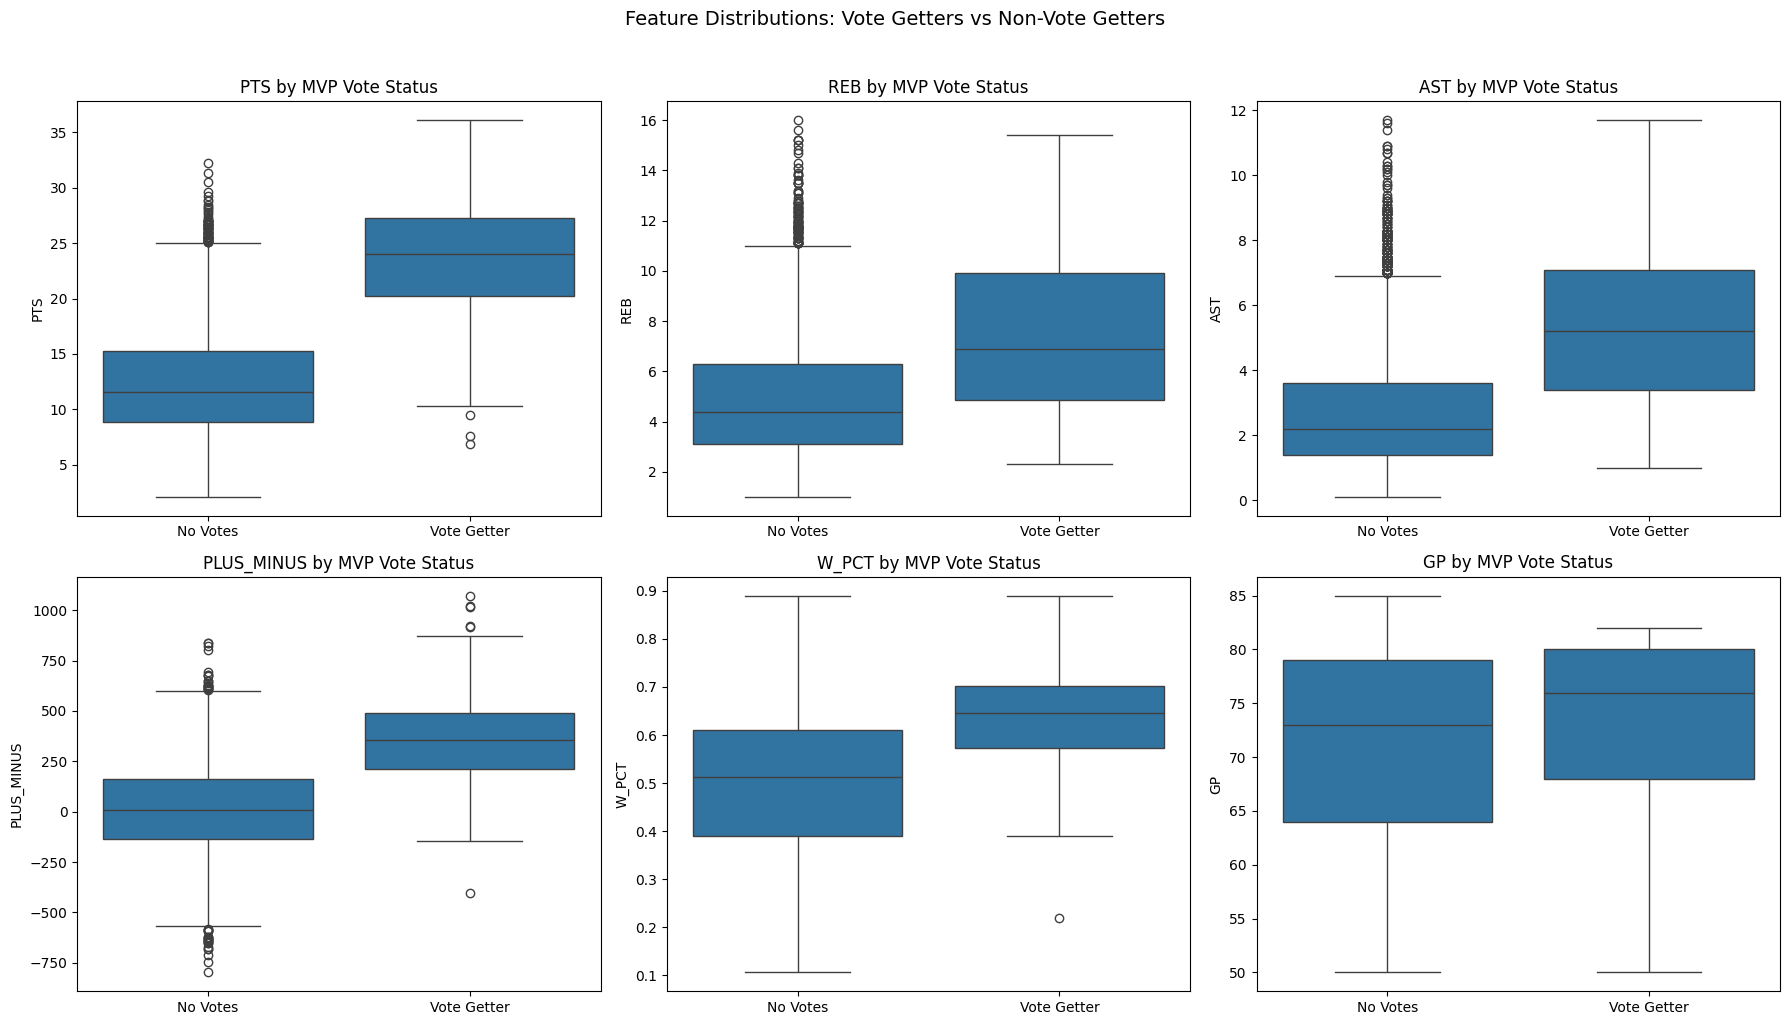

In [23]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

features = ['PTS', 'REB', 'AST', 'PLUS_MINUS', 'W_PCT', 'GP']

for ax, feature in zip(axes.flatten(), features):
    df['Vote Getter'] = df['MVP_SHARE'].apply(
        lambda x: 'Vote Getter' if x > 0 else 'No Votes'
    )
    
    sns.boxplot(data=df, x='Vote Getter', y=feature, ax=ax)
    ax.set_title(f'{feature} by MVP Vote Status')
    ax.set_xlabel('')

plt.suptitle('Feature Distributions: Vote Getters vs Non-Vote Getters', 
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()